#                                                        🛒 E-commerce Sales Analysis Project

This notebook performs end-to-end exploratory data analysis (EDA), customer segmentation, and visualization on an e-commerce dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/data.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


## Basic Info:-

We inspect data types, summary statistics, and basic structure of the dataset to understand its quality.

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Missing Values Check:-
 
We check for missing values in the dataset to identify incomplete or null data entries.

This helps us decide whether to drop or impute missing values before analysis.

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Data Cleaning:-
We clean the dataset by:

- Removing missing CustomerID values
- Converting InvoiceDate to datetime format
- Removing invalid transactions (Quantity ≤ 0, UnitPrice ≤ 0)
- Creating a new feature: TotalPrice

In [5]:
df = df.dropna(subset=['CustomerID'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Total Revenue:-

We calculate the total revenue generated by the e-commerce store.

In [6]:
df['TotalPrice'].sum()

np.float64(8911407.904)

## Monthly Sales Trend:-

We analyze how sales vary across different months to identify seasonal patterns.

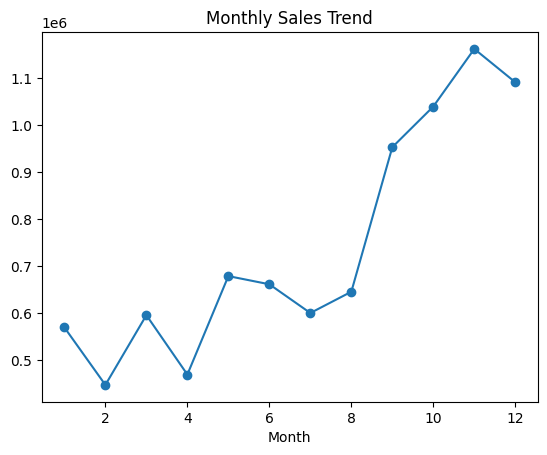

In [7]:
df['Month'] = df['InvoiceDate'].dt.month
monthly = df.groupby('Month')['TotalPrice'].sum()

monthly.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.show()

## Top Countries by Revenue:-

We identify which countries contribute the highest revenue to the business.

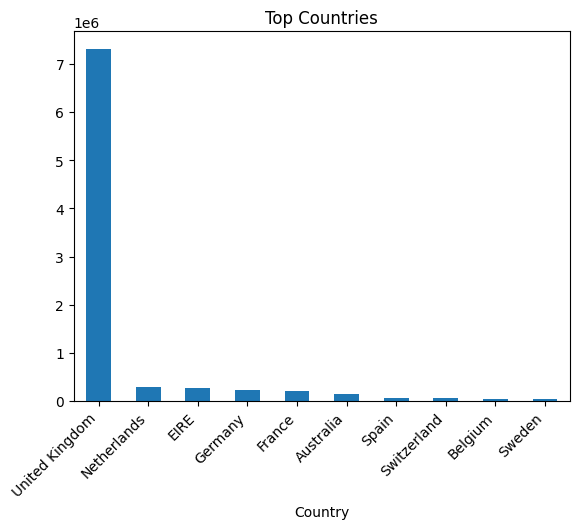

In [8]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar')
plt.title('Top Countries')
plt.xticks(rotation=45, ha='right')
plt.show()

## Top Selling Products:-

We find the most frequently sold products to understand customer demand.

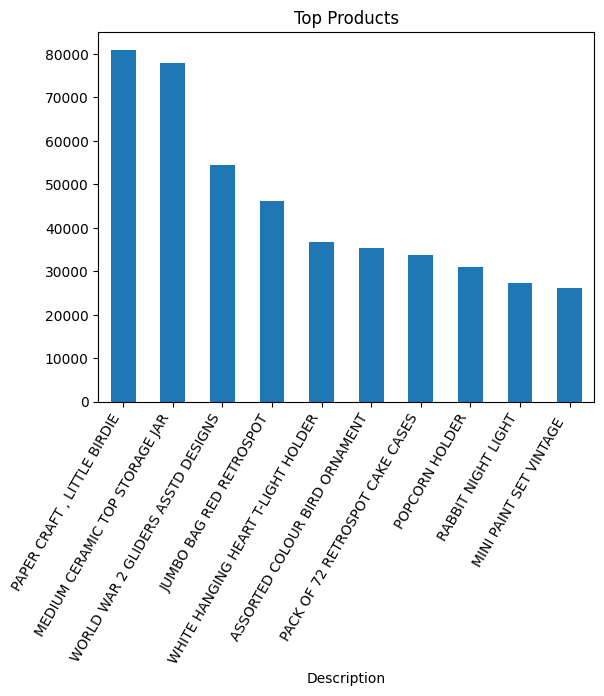

In [9]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')
plt.title('Top Products')
plt.xticks(rotation=60, ha='right')
plt.show()

## Revenue Distribution:-

We analyze how transaction values are distributed across all purchases.

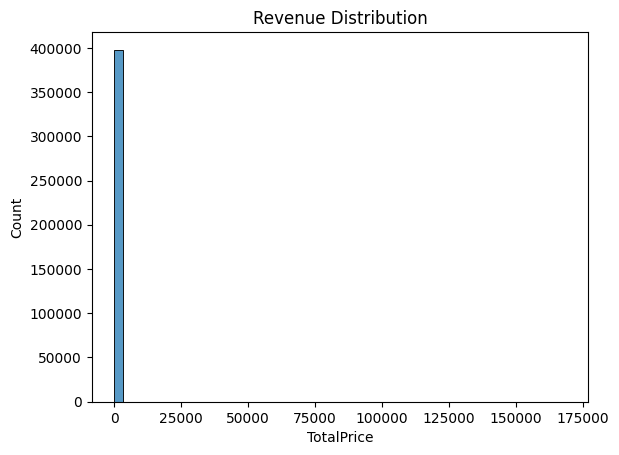

In [10]:
sns.histplot(df['TotalPrice'], bins=50)
plt.title('Revenue Distribution')
plt.show()

## Customer Segmentation (RFM Analysis):-

We segment customers based on:
- Recency (last purchase)
- Frequency (number of purchases)
- Monetary value (total spending)

This helps identify high-value customers.

In [11]:
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1) #(last date +1 day)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


RFM Visualization:-

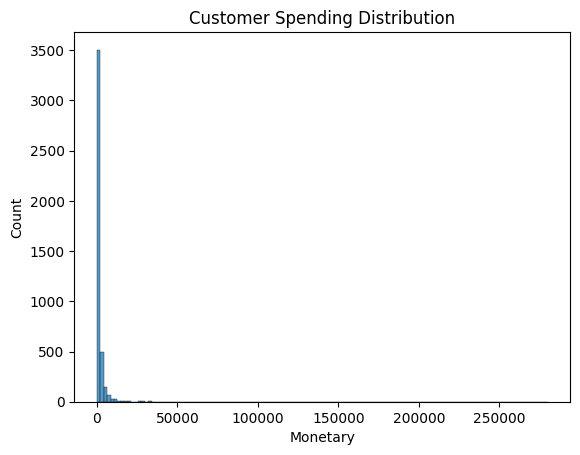

In [12]:
sns.histplot(rfm['Monetary'])
plt.title('Customer Spending Distribution')
plt.show()

## 🧠 Key Business Insights

-  Only a small segment of customers contributes the majority of revenue (Pareto Principle observed)
-  United Kingdom is the dominant market in terms of sales
-  A limited number of products generate most of the revenue
-  Strong seasonal trends observed in sales performance
-  RFM analysis effectively identifies loyal and high-value customers

## 🎯 Conclusion

This analysis provides actionable business insights that can support strategic decision-making in:

-  Marketing optimization
-  Customer targeting and retention
-  Inventory and supply chain planning
-  Revenue growth and forecasting